# Maven Music Dataset


Our plan is to use a supervised learning technique to predict which customers are most likely to cancel their subscription using **the past three months of customer data which includes subscription and listening history**.



# 2.1 Gather Data
# 2.2 Clean Data
# 2.3 EDA
# 2.4 Prep of Model

## 2.1 Gather Data

Read the following files into Python:
* Customer data: *maven_music_customers.csv*
* Listing history: *maven_music_listening_history.xlsx*

In [1]:
import pandas as pd

In [2]:
# Read in the customer data
cus_data=pd.read_csv("C:/Users/hp/Downloads/maven_music_customers.csv")
cus_data

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),$2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,$2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,$2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),$2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,$2.99,NaN,NaN
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,3/20/23,NaN,$2.99,NaN,6/3/23
6,5581,Reed Sharp,Email: sharp.tunes@email.com,3/21/23,Premium (No Ads),$9.99,NaN,NaN
7,5759,Carol Kingbird,Email: songbird.carol@email.com,3/22/23,Premium (No Ads),$9.99,NaN,6/2/23
8,5761,Sonata Nash,Email: musical.sonata@email.com,3/28/23,Premium (No Ads),$9.99,NaN,NaN
9,5763,Jazz Coleman,Email: coleman.jazzmaster@email.com,3/28/23,Basic (Ads),$2.99,NaN,NaN


In [3]:
# Read in the listening history
lis_data=pd.read_excel("C:/Users/hp/Downloads/maven_music_listening_history.xlsx")
lis_data

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song
...,...,...,...,...,...
500,7579,111282,4,111,Song
501,6588,111286,1,201,Podcast
502,5763,111333,1,110,Song
503,5763,111333,2,108,Song


In [4]:
# Read in the audio data
audio=pd.read_excel("C:/Users/hp/Downloads/maven_music_listening_history.xlsx",sheet_name="audio_files")
audio

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5
3,Song-104,Glowing Hearts,Pop Music,10
4,Song-105,Pop Rocks,Pop Music,52
5,Song-106,My Old Dog and My True Love,Country,23
6,Song-107,Dirt Road Romance,Country,30
7,Song-108,Chase the Dream,Hip Hop,4
8,Song-109,Rise Above,Hip Hop,9
9,Song-110,Boss Moves,Hip Hop,28


In [5]:
# Read in the session data
session=pd.read_excel("C:/Users/hp/Downloads/maven_music_listening_history.xlsx",sheet_name="session_login_time")
session

,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00
...,...,...
85,111263,2023-05-20 15:17:30
86,111273,2023-05-20 16:01:00
87,111282,2023-05-23 23:51:00
88,111286,2023-05-27 02:15:00


## 2.2 Clean Data

### a. Convert Data Types

Check the data types of the data in the tables and convert to numeric and datetime values as necessary.

In [6]:
cus_data.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),$2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,$2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,$2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),$2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,$2.99,NaN,NaN


In [7]:
lis_data.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [8]:
lis_data.dtypes

Customer ID     int64
Session ID      int64
Audio Order     int64
Audio ID        int64
Audio Type     object
dtype: object

In [9]:
audio.head()

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5
3,Song-104,Glowing Hearts,Pop Music,10
4,Song-105,Pop Rocks,Pop Music,52


In [10]:
audio.dtypes

ID            object
Name          object
Genre         object
Popularity     int64
dtype: object

In [11]:
session.head()

,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00


In [12]:
session.dtypes

Session ID                      int64
Session Log In Time    datetime64[ns]
dtype: object

In [13]:
# Check the data types
cus_data.dtypes

Customer ID           int64
Customer Name        object
Email                object
Member Since         object
Subscription Plan    object
Subscription Rate    object
Discount?            object
Cancellation Date    object
dtype: object

In [14]:
# Convert objects to numeric and datetime fields
cus_data["Member Since"]=cus_data["Member Since"].astype("datetime64[ns]")
cus_data["Cancellation Date"]=cus_data["Cancellation Date"].astype("datetime64[ns]")

In [15]:
cus_data["Subscription Rate"]=cus_data["Subscription Rate"].str.replace('$','')
cus_data["Subscription Rate"]=pd.to_numeric(cus_data["Subscription Rate"])

In [16]:
cus_data.dtypes

Customer ID                   int64
Customer Name                object
Email                        object
Member Since         datetime64[ns]
Subscription Plan            object
Subscription Rate           float64
Discount?                    object
Cancellation Date    datetime64[ns]
dtype: object

### b. Resolve Data Issues

Check for missing data, inconsistent text and typos, duplicate data and outliers.

#### i. Missing Data

In [17]:
# Look for NaN values in the data
cus_data.isnull().sum()

Customer ID           0
Customer Name         0
Email                 0
Member Since          0
Subscription Plan     5
Subscription Rate     0
Discount?            23
Cancellation Date    17
dtype: int64

In [18]:
cus_data[cus_data.isna().any(axis=1)]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,NaN,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,NaN,2.99,NaN,2023-06-03
6,5581,Reed Sharp,Email: sharp.tunes@email.com,2023-03-21,Premium (No Ads),9.99,NaN,NaT
7,5759,Carol Kingbird,Email: songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,NaN,2023-06-02
8,5761,Sonata Nash,Email: musical.sonata@email.com,2023-03-28,Premium (No Ads),9.99,NaN,NaT
9,5763,Jazz Coleman,Email: coleman.jazzmaster@email.com,2023-03-28,Basic (Ads),2.99,NaN,NaT


In [19]:
lis_data.isnull().sum()

Customer ID    0
Session ID     0
Audio Order    0
Audio ID       0
Audio Type     0
dtype: int64

In [20]:
audio.isnull().sum()

ID            0
Name          0
Genre         0
Popularity    0
dtype: int64

In [21]:
session.isnull().sum()

Session ID             0
Session Log In Time    0
dtype: int64

#### ii. Inconsistent Text & Typos

In [22]:
# Look for inconsistent text & typos
cus_data["Subscription Plan"].value_counts()

Subscription Plan
Premium (No Ads)    13
Basic (Ads)         12
Name: count, dtype: int64

In [23]:
lis_data["Audio Type"].value_counts()

Audio Type
Song       463
Podcast     42
Name: count, dtype: int64

In [24]:
audio["Genre"].value_counts()

Genre
Pop Music     3
Comedy        3
Hip Hop       3
Country       2
Pop           2
Jazz          2
True Crime    2
Name: count, dtype: int64

In [26]:
import numpy as np

In [27]:
audio["Genre"]=np.where(audio["Genre"]=="Pop Music","Pop",audio["Genre"])

In [28]:
audio["Genre"].value_counts()

Genre
Pop           5
Hip Hop       3
Comedy        3
Country       2
Jazz          2
True Crime    2
Name: count, dtype: int64

#### iii. Duplicate Rows

In [29]:
# Look for duplicate rows
cus_data[cus_data.duplicated(keep=False)]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date


In [30]:
lis_data[lis_data.duplicated(keep=False)]

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type


In [31]:
audio[audio.duplicated(keep=False)]

,ID,Name,Genre,Popularity


In [32]:
session[session.duplicated(keep=False)]

,Session ID,Session Log In Time


#### iv. Outliers

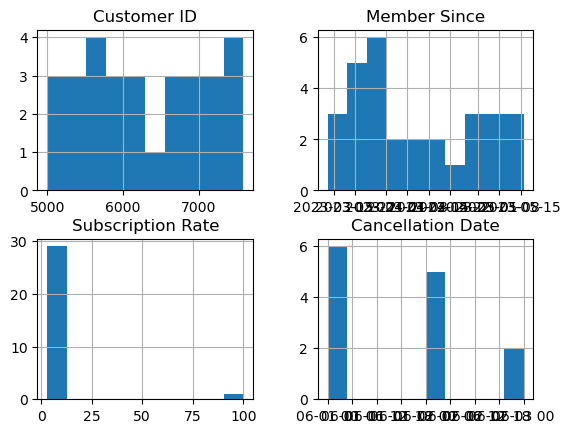

In [33]:
# Look for outliers
cus_data.hist();

In [34]:
sns.boxplot(x=cus_data["Subscription Rate"]);

NameError: name 'sns' is not defined

In [ ]:
lis_data.hist();

In [ ]:
sns.boxplot(x=lis_data["Audio Order"]);

In [ ]:
sns.boxplot(x=lis_data["Audio ID"]);

In [35]:
lis_data["Audio ID"].value_counts()

Audio ID
103    71
101    52
105    50
102    48
104    46
110    38
106    37
107    31
109    28
111    28
108    22
112    20
204     9
202     9
205     6
201     6
203     4
Name: count, dtype: int64

In [36]:
lis_data["Audio Order"].value_counts()

Audio Order
1     90
2     80
3     71
4     66
5     58
6     44
7     37
8     26
9     13
10     8
11     5
12     4
13     1
14     1
15     1
Name: count, dtype: int64

In [37]:
cus_data["Subscription Rate"]=np.where(cus_data["Subscription Rate"]>40,cus_data["Subscription Rate"].mean(),cus_data["Subscription Rate"])

In [39]:
import seaborn as sns

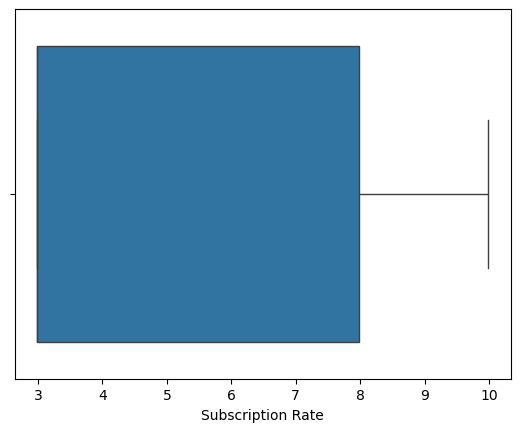

In [40]:
sns.boxplot(x=cus_data["Subscription Rate"]);

### c. Create New Columns

Create two new columns that will be useful for EDA and modeling:
* Cancelled: whether a customer cancelled or not
* Email: Remove the "Email:" from the email addresses

In [41]:
cus_data.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,NaN,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT


In [42]:
# Create a 'Cancelled' column
cus_data["Cancelled"]=np.where(cus_data["Cancellation Date"].isnull(), "NotCancelled", "Cancelled")

In [43]:
cus_data.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT,NotCancelled
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT,NotCancelled
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01,Cancelled
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,NaN,NaT,NotCancelled
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT,NotCancelled


In [44]:
# Create an updated 'Email' column without the Email: portion
cus_data["Email"]=cus_data["Email"].str.replace('Email:','')

In [45]:
cus_data.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT,NotCancelled
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT,NotCancelled
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01,Cancelled
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,NaN,NaT,NotCancelled
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT,NotCancelled


## 2.3 EDA

Try to better understand the customers who cancelled:
* How long were they members before they cancelled?
* What percentage of customers who cancelled had a discount vs customers who didn't cancel?

In [46]:
# How long were customers members before they cancelled?
# Filter only cancelled customers
cancelled = cus_data[cus_data["Cancellation Date"].notna()]

# Calculate membership duration
cancelled["Membership_Duration_Days"] = (cancelled["Cancellation Date"] - cancelled["Member Since"]).dt.days

# Display average duration
cancelled["Membership_Duration_Days"].describe()

C:\Users\hp\AppData\Local\Temp\ipykernel_7048\3899399599.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cancelled["Membership_Duration_Days"] = (cancelled["Cancellation Date"] - cancelled["Member Since"]).dt.days


count    13.000000
mean     46.307692
std      23.135055
min      16.000000
25%      24.000000
50%      46.000000
75%      65.000000
max      80.000000
Name: Membership_Duration_Days, dtype: float64

In [47]:
# Cancellation rate for those who had a discount
# Customers who received a discount
discount_group = cus_data[cus_data["Discount?"] == "Yes"]

# Cancellation rate
discount_cancel_rate = (discount_group["Cancellation Date"].notna().mean()) * 100
discount_cancel_rate

np.float64(85.71428571428571)

In [48]:
# Cancellation rate for those who did not have a discount
# Customers without a discount
no_discount_group = cus_data[cus_data["Discount?"] == "No"]

# Cancellation rate
no_discount_cancel_rate = (no_discount_group["Cancellation Date"].notna().mean()) * 100
no_discount_cancel_rate

nan

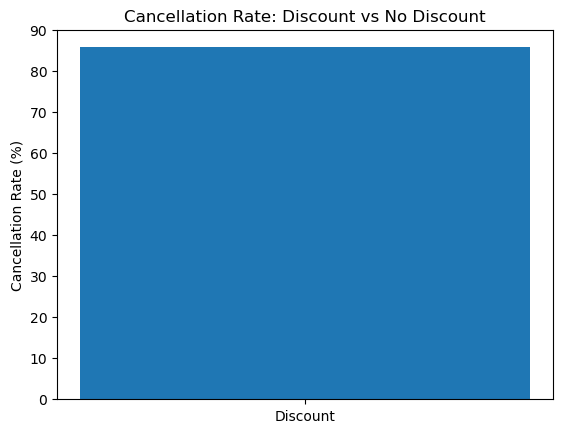

In [49]:
# Visualize the cancellation rate for those with a discount vs those without a discount
import matplotlib.pyplot as plt

labels = ["Discount", "No Discount"]
rates = [discount_cancel_rate, no_discount_cancel_rate]

plt.bar(labels, rates)
plt.ylabel("Cancellation Rate (%)")
plt.title("Cancellation Rate: Discount vs No Discount")
plt.show()

Better understand the customers' listening histories:
* Join together the listening history and audio tables
* How many listening sessions did each customer have in the past 3 months?
* What were the most popular genres that customers listened to?

In [56]:
lis_data

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song
...,...,...,...,...,...
500,7579,111282,4,111,Song
501,6588,111286,1,201,Podcast
502,5763,111333,1,110,Song
503,5763,111333,2,108,Song


In [52]:
audio

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop,5
3,Song-104,Glowing Hearts,Pop,10
4,Song-105,Pop Rocks,Pop,52
5,Song-106,My Old Dog and My True Love,Country,23
6,Song-107,Dirt Road Romance,Country,30
7,Song-108,Chase the Dream,Hip Hop,4
8,Song-109,Rise Above,Hip Hop,9
9,Song-110,Boss Moves,Hip Hop,28


In [53]:
# Split the ID in the audio data so the column can be joined with other tables
# Clean Audio ID so it matches the Listening History table
audio["Audio_ID_Clean"] = audio["ID"].str.extract("(\d+)", expand=False).astype(int)
audio.head()

,ID,Name,Genre,Popularity,Audio_ID_Clean
0,Song-101,Dance All Night,Pop,1,101
1,Song-102,Unbreakable Beat,Pop,2,102
2,Song-103,Sunset Boulevard,Pop,5,103
3,Song-104,Glowing Hearts,Pop,10,104
4,Song-105,Pop Rocks,Pop,52,105


In [57]:
# Hint: Check the data type of Audio ID in the audio table
lis_data["Audio ID"].dtype, audio["Audio_ID_Clean"].dtype

(dtype('int64'), dtype('int64'))

In [58]:
# Merge listening history (listening) with audio table using cleaned Audio ID
merged = lis_data.merge(audio, left_on="Audio ID", right_on="Audio_ID_Clean", how="left")
merged.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,ID,Name,Genre,Popularity,Audio_ID_Clean
0,5001,100520,1,101,Song,Song-101,Dance All Night,Pop,1,101
1,5001,100520,2,102,Song,Song-102,Unbreakable Beat,Pop,2,102
2,5001,100520,3,103,Song,Song-103,Sunset Boulevard,Pop,5,103
3,5001,100520,4,104,Song,Song-104,Glowing Hearts,Pop,10,104
4,5001,100520,5,105,Song,Song-105,Pop Rocks,Pop,52,105


In [59]:
# The most popular genres that customers listened to
popular_genres = merged["Genre"].value_counts().reset_index()
popular_genres.columns = ["Genre", "Count"]
popular_genres

,Genre,Count
0,Pop,267
1,Hip Hop,88
2,Country,68
3,Jazz,48
4,Comedy,19
5,True Crime,15


## 2.4 Prep for Modeling

Create a DataFrame that is ready for modeling with each row representing a customer and the following numeric, non-null columns:
* Customer ID
* Whether a customer cancelled or not
* Whether a customer received a discount or not
* The number of listening sessions
* Percent of listening history consisting of Pop
* Percent of listening history consisting of Podcasts

In [61]:
# Calculate the number of listening sessions for each customer
sessions = merged.groupby("Customer ID").size().rename("num_listening_sessions").reset_index()
sessions

,Customer ID,num_listening_sessions
0,5001,60
1,5002,22
2,5004,9
3,5267,45
4,5338,18
5,5404,8
6,5581,5
7,5759,15
8,5761,5
9,5763,31


In [62]:
# Percent pop
if "Genre" in merged.columns:
    genre_counts = merged.groupby(["Customer ID","Genre"]).size().rename("count").reset_index()
    total_counts = merged.groupby("Customer ID").size().rename("total_count").reset_index()
    genre_pct = genre_counts.merge(total_counts, on="Customer ID")
    genre_pct["pct"] = genre_pct["count"] / genre_pct["total_count"]

    # Extract percent Pop
    pop_pct = genre_pct[genre_pct["Genre"].str.lower().str.contains("pop", na=False)].groupby("Customer ID")["pct"].sum().rename("pct_pop").reset_index()
    # Extract percent Podcasts (genre string contains 'podcast' or 'podcasts')
    podcast_pct = genre_pct[genre_pct["Genre"].str.lower().str.contains("podcast", na=False)].groupby("Customer ID")["pct"].sum().rename("pct_podcast").reset_index()
else:
    # If no Genre column, create empty pct series
    pop_pct = pd.DataFrame(columns=["Customer ID", "pct_pop"])
    podcast_pct = pd.DataFrame(columns=["Customer ID", "pct_podcast"])


In [64]:
model_df = cus_data[["Customer ID", "Cancelled", "Discount?"]].drop_duplicates(subset=["Customer ID"]).copy()

# Merge sessions (fill 0 where missing)
model_df = model_df.merge(sessions, on="Customer ID", how="left")
model_df["num_listening_sessions"] = model_df["num_listening_sessions"].fillna(0).astype(int)

# Merge pct_pop and pct_podcast (fill 0 where missing)
model_df = model_df.merge(pop_pct, on="Customer ID", how="left")
model_df = model_df.merge(podcast_pct, on="Customer ID", how="left")
model_df["pct_pop"] = model_df["pct_pop"].fillna(0.0)
model_df["pct_podcast"] = model_df["pct_podcast"].fillna(0.0)

# Ensure numeric non-null columns (replace NaNs if any)
numeric_cols = ["Cancelled", "Discount?", "num_listening_sessions", "pct_pop", "pct_podcast"]
for c in numeric_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce").fillna(0)

# Final check: one row per customer
model_df = model_df.drop_duplicates(subset=["Customer ID"]).reset_index(drop=True)

# Show result
model_df.head(), model_df[numeric_cols].describe()

(   Customer ID  Cancelled  Discount?  num_listening_sessions   pct_pop  \
 0         5001        0.0        0.0                      60  0.566667   
 1         5002        0.0        0.0                      22  0.000000   
 2         5004        0.0        0.0                       9  1.000000   
 3         5267        0.0        0.0                      45  0.511111   
 4         5338        0.0        0.0                      18  0.000000   
 
    pct_podcast  
 0          0.0  
 1          0.0  
 2          0.0  
 3          0.0  
 4          0.0  ,
        Cancelled  Discount?  num_listening_sessions    pct_pop  pct_podcast
 count       30.0       30.0               30.000000  30.000000         30.0
 mean         0.0        0.0               16.833333   0.466872          0.0
 std          0.0        0.0               12.641157   0.405194          0.0
 min          0.0        0.0                2.000000   0.000000          0.0
 25%          0.0        0.0                9.000000  